# 02 — Feature Engineering

**Goal**: Compute and save numerical feature matrices from peptide sequences.

We extract three families of features:
1. **AAC**: Amino Acid Composition (20 dims)
2. **DPC**: Dipeptide Composition (400 dims)
3. **Physicochemical Stats**: length, charge, aromaticity, hydrophobicity (7 dims)
4. **k-mers**: Binary k-mer presence (k=2 -> 400 dims)

These are imported from `src/features.py` to ensure reusability.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add root project dir to path so we can import src
sys.path.append(os.path.abspath('..'))
from src.features import (
    compute_aac, compute_dpc, compute_seq_stats, compute_kmer_fingerprint,
    AAC_NAMES, get_dipeptide_names, SEQ_STAT_NAMES
)

plt.style.use('dark_background')
print('Libraries and src module loaded ✓')

Libraries and src module loaded ✓


## Step 2.1 — Load Cleaned Data

In [11]:
train_df = pd.read_csv('../data/processed/train_clean.csv')
test_df  = pd.read_csv('../data/processed/test_clean.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')

Train shape: (7143, 3)
Test  shape: (1917, 3)


## Step 2.2 — Compute Core Features (AAC, DPC, Stats)

In [12]:
%%time
print('Computing AAC...')
X_train_aac = compute_aac(train_df['Sequence'])
X_test_aac  = compute_aac(test_df['Sequence'])

print('Computing DPC...')
X_train_dpc = compute_dpc(train_df['Sequence'])
X_test_dpc  = compute_dpc(test_df['Sequence'])

print('Computing Physicochemical Stats...')
X_train_stats = compute_seq_stats(train_df['Sequence'])
X_test_stats  = compute_seq_stats(test_df['Sequence'])

print('Computing 2-mer binary fingerprints...')
X_train_kmer2 = compute_kmer_fingerprint(train_df['Sequence'], k=2)
X_test_kmer2  = compute_kmer_fingerprint(test_df['Sequence'],  k=2)


print(f'AAC shape:   {X_train_aac.shape}')
print(f'DPC shape:   {X_train_dpc.shape}')
print(f'Stats shape: {X_train_stats.shape}')
print(f'2-mer shape: {X_train_kmer2.shape}')

Computing AAC...
Computing DPC...
Computing Physicochemical Stats...
Computing 2-mer binary fingerprints...
AAC shape:   (7143, 20)
DPC shape:   (7143, 400)
Stats shape: (7143, 7)
2-mer shape: (7143, 400)
CPU times: total: 391 ms
Wall time: 385 ms


## Step 2.3 — Concatenate and Save Feature Matrices

In [13]:
X_train_all = np.hstack([X_train_aac, X_train_dpc, X_train_stats, X_train_kmer2])
X_test_all  = np.hstack([X_test_aac,  X_test_dpc,  X_test_stats,  X_test_kmer2])

print(f'Combined Train Features: {X_train_all.shape}')
print(f'Combined Test Features:  {X_test_all.shape}')

# Assert no NaNs
assert not np.isnan(X_train_all).any(), "NaNs found in train features"
assert not np.isnan(X_test_all).any(),  "NaNs found in test features"
assert not np.isinf(X_train_all).any(), "Infs found in train features"
assert not np.isinf(X_test_all).any(),  "Infs found in test features"

# Construct feature names
dpc_names = get_dipeptide_names()
kmer2_names = [f'kmer2_{km}' for km in dpc_names] # Same space as DPC
feature_names = AAC_NAMES + dpc_names + SEQ_STAT_NAMES + kmer2_names
assert len(feature_names) == X_train_all.shape[1]

# Save as DataFrames to preserve names (or Numpy/Pickle for speed)
df_X_train = pd.DataFrame(X_train_all, columns=feature_names)
df_X_test  = pd.DataFrame(X_test_all,  columns=feature_names)

df_X_train.to_pickle('../data/processed/X_train_features.pkl')
df_X_test.to_pickle('../data/processed/X_test_features.pkl')
train_df['Label'].to_pickle('../data/processed/y_train.pkl')

print('Saved features to data/processed/*.pkl')

Combined Train Features: (7143, 827)
Combined Test Features:  (1917, 827)
Saved features to data/processed/*.pkl


## Step 2.4 — Correlation Analysis (Physicochemical Stats)

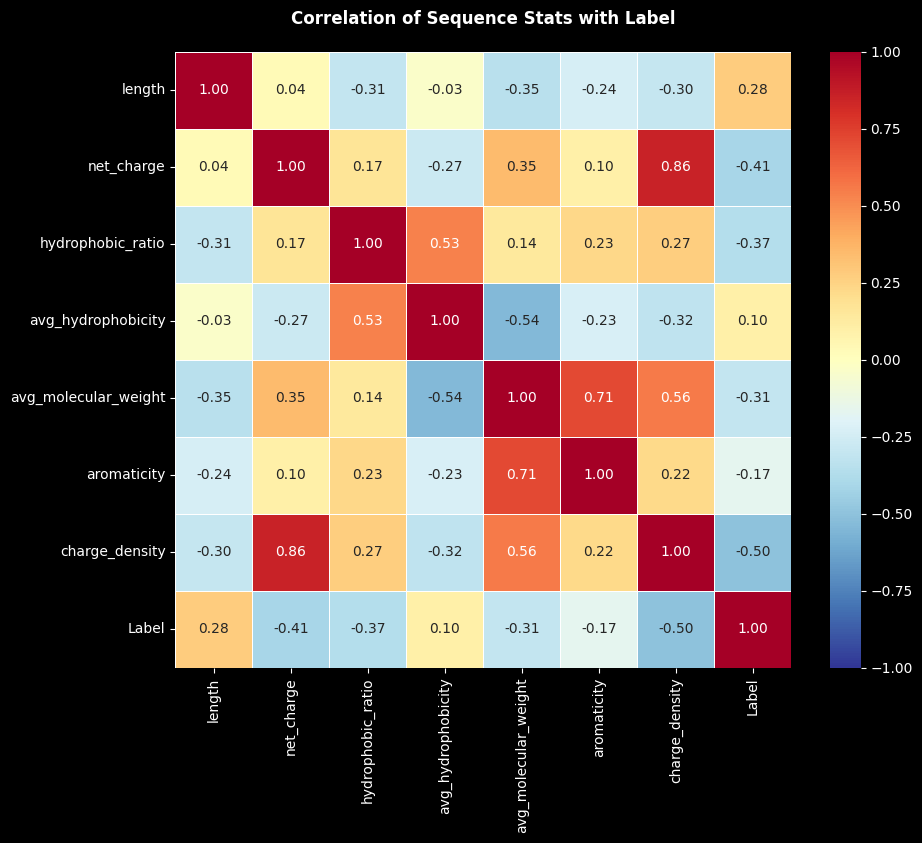

In [14]:
# Quick look at how the sequence stats correlate with the target Label
stats_df = pd.DataFrame(X_train_stats, columns=SEQ_STAT_NAMES)
stats_df['Label'] = train_df['Label']

plt.figure(figsize=(10, 8))
sns.heatmap(stats_df.corr(), annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation of Sequence Stats with Label', fontweight='bold', pad=20)
plt.show()

## Step 2.X — Advanced Physicochemical Features
Using `iFeatureOmegaCLI` to generate CTD (Composition, Transition, Distribution) and PseAAC features.
(Assumes `pip install iFeatureOmegaCLI` is installed)


In [15]:
!pip install -q --upgrade setuptools
!pip install -q biopython
!pip install -q iFeatureOmegaCLI --no-deps

In [18]:
# Install if not already installed (Python 3.12: setuptools + --no-deps to avoid broken deps)
!pip install -q --upgrade setuptools
!pip install -q biopython
!pip install -q iFeatureOmegaCLI --no-deps

import os
from iFeatureOmegaCLI import iProtein
import pandas as pd

# We need to temporarily write sequences to a FASTA file for iProtein to consume
def sequences_to_fasta(sequences, labels, filepath):
    with open(filepath, 'w') as f:
        for i, (seq, label) in enumerate(zip(sequences, labels)):
            f.write(f'>Seq_{i}|{label}\n{seq}\n')

train_df = pd.read_csv('../data/processed/train_clean.csv')
fasta_path = '../data/processed/temp_train.fasta'
sequences_to_fasta(train_df['Sequence'].values, train_df['Label'].values, fasta_path)

# Initialize iProtein
obj = iProtein(file=fasta_path)

# Compute CTD (Composition, Transition, Distribution) — three descriptors in this package
obj.get_descriptor('CTDC')
ctdc = obj.encodings
obj.get_descriptor('CTDT')
ctdt = obj.encodings
obj.get_descriptor('CTDD')
ctdd = obj.encodings
ctd_features = pd.concat([ctdc, ctdt, ctdd], axis=1)
print(f'CTD features shape: {ctd_features.shape}')

# Compute PseAAC (Pseudo Amino Acid Composition) — descriptor name is 'PAAC' in this package
try:
    obj.get_descriptor('PAAC')
    pseaac_features = obj.encodings
    print(f'PseAAC (PAAC) features shape: {pseaac_features.shape}')
except Exception as e:
    print(f"Warning: Could not compute PseAAC, error: {e}")

# Clean up temp
if os.path.exists(fasta_path):
    os.remove(fasta_path)
    
print('Ready to concatenate these features to X_train_features!')


CTD features shape: (7143, 273)
PseAAC (PAAC) features shape: (7143, 23)
Ready to concatenate these features to X_train_features!
